In [19]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import h5py

from keras.models import *
from keras.layers import *
from keras.optimizers import *
from keras import backend as keras
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, LearningRateScheduler
from keras.models import load_model

# GPU調整

In [20]:
os.environ["CUDA_VISIBLE_DEVICES"] = "0,1"
cfg = tf.compat.v1.ConfigProto() 
cfg.gpu_options.visible_device_list="0"
cfg.gpu_options.allow_growth=True
cfg.gpu_options.per_process_gpu_memory_fraction = 0.7# 使用50%的GPU暫存  
session = tf.compat.v1.Session(config=cfg )

In [21]:
def solve_cudnn_error():
    gpus = tf.config.experimental.list_physical_devices('GPU')
    if gpus:
        try:
            # Currently, memory growth needs to be the same across GPUs
            for gpu in gpus:
                tf.config.experimental.set_memory_growth(gpu, True)
            logical_gpus = tf.config.experimental.list_logical_devices('GPU')
            print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
        except RuntimeError as e:
            # Memory growth must be set before GPUs have been initialized
            print(e)

In [22]:
solve_cudnn_error()

1 Physical GPUs, 1 Logical GPUs


# Train dliate 遮罩製作

In [5]:
data_folder = 'train/image/'
mask_folder = 'train/mask/'
DILATE_KERNEL = np.ones((9, 9), np.uint8)
for filename in os.listdir(data_folder):
    img = cv2.imread(os.path.join(data_folder, filename))
    mask_img = cv2.imread(os.path.join(mask_folder, filename), cv2.IMREAD_GRAYSCALE)
    if img.shape !=(512,512,3):
        print(filename)
        img=cv2.resize(img,(512,512))
        mask_img=cv2.resize(mask_img,(512,512))
        cv2.imwrite("train\{}".format(filename),img)
        cv2.imwrite("train\mask{}".format(filename),mask_img)
    mask_dilate = cv2.dilate(mask_img, DILATE_KERNEL, iterations=1)
    cv2.imwrite("train\dilate\{}".format(filename),mask_dilate)
    

1.jpg
10.jpg
100.jpg
1000.jpg
1001.jpg
1002.jpg
1003.jpg
1004.jpg
1005.jpg
1006.jpg
1007.jpg
1008.jpg
1009.jpg
101.jpg
1010.jpg
1011.jpg
1012.jpg
1013.jpg
1014.jpg
1015.jpg
1016.jpg
1017.jpg
1018.jpg
1019.jpg
102.jpg
1020.jpg
1021.jpg
1022.jpg
1023.jpg
1024.jpg
1025.jpg
1026.jpg
1027.jpg
1028.jpg
1029.jpg
103.jpg
1030.jpg
1031.jpg
1032.jpg
1033.jpg
1034.jpg
1035.jpg
1036.jpg
1037.jpg
1038.jpg
1039.jpg
104.jpg
1040.jpg
1041.jpg
1042.jpg
1043.jpg
1044.jpg
1045.jpg
1046.jpg
1047.jpg
1048.jpg
1049.jpg
105.jpg
1050.jpg
1051.jpg
1052.jpg
1053.jpg
1054.jpg
1055.jpg
1056.jpg
1057.jpg
1058.jpg
1059.jpg
106.jpg
1060.jpg
1061.jpg
1062.jpg
1063.jpg
1064.jpg
1065.jpg
1066.jpg
1067.jpg
1068.jpg
1069.jpg
107.jpg
1070.jpg
1071.jpg
1072.jpg
1073.jpg
1074.jpg
1075.jpg
1076.jpg
1077.jpg
1078.jpg
1079.jpg
108.jpg
1080.jpg
1081.jpg
1082.jpg
1083.jpg
1084.jpg
1085.jpg
1086.jpg
1087.jpg
1088.jpg
1089.jpg
109.jpg
1090.jpg
1091.jpg
1092.jpg
1093.jpg
1094.jpg
1095.jpg
1096.jpg
1097.jpg
1098.jpg
1099.jpg
11.jpg


37.jpg
370.jpg
371.jpg
372.jpg
373.jpg
374.jpg
375.jpg
376.jpg
377.jpg
378.jpg
379.jpg
38.jpg
380.jpg
381.jpg
382.jpg
383.jpg
384.jpg
385.jpg
386.jpg
387.jpg
388.jpg
389.jpg
39.jpg
390.jpg
391.jpg
392.jpg
393.jpg
394.jpg
395.jpg
396.jpg
397.jpg
398.jpg
399.jpg
4.jpg
40.jpg
400.jpg
401.jpg
402.jpg
403.jpg
404.jpg
405.jpg
406.jpg
407.jpg
408.jpg
409.jpg
41.jpg
410.jpg
411.jpg
412.jpg
413.jpg
414.jpg
415.jpg
416.jpg
417.jpg
418.jpg
419.jpg
42.jpg
420.jpg
421.jpg
422.jpg
423.jpg
424.jpg
425.jpg
426.jpg
427.jpg
428.jpg
429.jpg
43.jpg
430.jpg
431.jpg
432.jpg
433.jpg
434.jpg
435.jpg
436.jpg
437.jpg
438.jpg
439.jpg
44.jpg
440.jpg
441.jpg
442.jpg
443.jpg
444.jpg
445.jpg
446.jpg
447.jpg
448.jpg
449.jpg
45.jpg
450.jpg
451.jpg
452.jpg
453.jpg
454.jpg
455.jpg
456.jpg
457.jpg
458.jpg
459.jpg
46.jpg
460.jpg
461.jpg
462.jpg
463.jpg
464.jpg
465.jpg
466.jpg
467.jpg
468.jpg
469.jpg
47.jpg
470.jpg
471.jpg
472.jpg
473.jpg
474.jpg
475.jpg
476.jpg
477.jpg
478.jpg
479.jpg
48.jpg
480.jpg
481.jpg
482.jpg
483.jp

# Test dilate 製作

In [18]:
data_folder = 'test/image/'
mask_folder = 'test/mask/'
DILATE_KERNEL = np.ones((15, 15), np.uint8)
for filename in os.listdir(data_folder):
    img = cv2.imread(os.path.join(data_folder, filename))
    mask_img = cv2.imread(os.path.join(mask_folder, filename), cv2.IMREAD_GRAYSCALE)
    if img.shape !=(512,512,3):
        print(filename)
        img=cv2.resize(img,(512,512))
        mask_img=cv2.resize(mask_img,(512,512))
    mask_dilate = cv2.dilate(mask_img, DILATE_KERNEL, iterations=1)
    cv2.imwrite("test\dilate\{}".format(filename),mask_dilate)

In [23]:
def add_colored_dilate(image, mask_image, dilate_image):
    mask_image_gray = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    dilate_image_gray = cv2.cvtColor(dilate_image, cv2.COLOR_BGR2GRAY)
    
    mask = cv2.bitwise_and(mask_image, mask_image, mask=mask_image_gray)
    dilate = cv2.bitwise_and(dilate_image, dilate_image, mask=dilate_image_gray)
    
    mask_coord = np.where(mask!=[0,0,0])
    dilate_coord = np.where(dilate!=[0,0,0])

    mask[mask_coord[0],mask_coord[1],:]=[255,0,0]
    dilate[dilate_coord[0],dilate_coord[1],:] = [0,0,255]

    ret = cv2.addWeighted(image, 0.7, dilate, 0.3, 0)
    ret = cv2.addWeighted(ret, 0.7, mask, 0.3, 0)

    return ret

In [24]:
def add_colored_mask(image, mask_image):
    mask_image_gray = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    
    mask = cv2.bitwise_and(mask_image, mask_image, mask=mask_image_gray)
    
    mask_coord = np.where(mask!=[0,0,0])

    mask[mask_coord[0],mask_coord[1],:]=[255,0,0]

    ret = cv2.addWeighted(image, 0.7, mask, 0.3, 0)

    return ret

In [25]:
def diff_mask(ref_image, mask_image):
    mask_image_gray = cv2.cvtColor(mask_image, cv2.COLOR_BGR2GRAY)
    
    mask = cv2.bitwise_and(mask_image, mask_image, mask=mask_image_gray)
    
    mask_coord = np.where(mask!=[0,0,0])

    mask[mask_coord[0],mask_coord[1],:]=[255,0,0]

    ret = cv2.addWeighted(ref_image, 0.7, mask, 0.3, 0)
    return ret

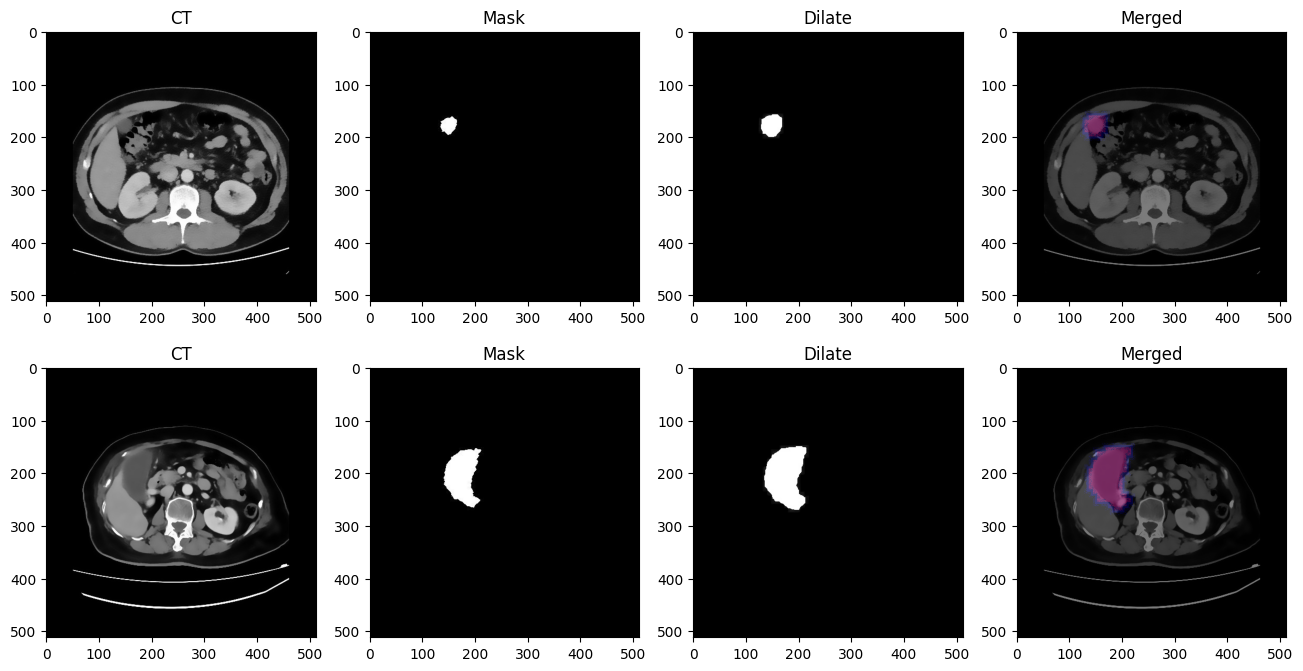

In [26]:
data_folder = 'train/image/'
mask_folder = 'train/mask/'
dilate_folder="train/dilate/"
base_file = os.listdir(data_folder)

image_file = os.path.join(data_folder, base_file[10])
mask_image_file = os.path.join(mask_folder, base_file[10])
dilate_image_file = os.path.join(dilate_folder, base_file[10])

image = cv2.imread(image_file)
mask_image = cv2.imread(mask_image_file)
dilate_image = cv2.imread(dilate_image_file)
merged_image = add_colored_dilate(image, mask_image, dilate_image)
                          
fig, axs = plt.subplots(2, 4, figsize=(16, 8))

axs[0, 0].set_title("CT")
axs[0, 0].imshow(image)

axs[0, 1].set_title("Mask")
axs[0, 1].imshow(mask_image)

axs[0, 2].set_title("Dilate")
axs[0, 2].imshow(dilate_image)

axs[0, 3].set_title("Merged")
axs[0, 3].imshow(merged_image)

image_file = os.path.join(data_folder, base_file[52])
mask_image_file = os.path.join(mask_folder, base_file[52])
dilate_image_file = os.path.join(dilate_folder, base_file[52])

image = cv2.imread(image_file)
mask_image = cv2.imread(mask_image_file)
dilate_image = cv2.imread(dilate_image_file)
merged_image = add_colored_dilate(image, mask_image, dilate_image)
axs[1, 0].set_title("CT")
axs[1, 0].imshow(image)

axs[1, 1].set_title("Mask")
axs[1, 1].imshow(mask_image)

axs[1, 2].set_title("Dilate")
axs[1, 2].imshow(dilate_image)

axs[1, 3].set_title("Merged")
axs[1, 3].imshow(merged_image)

In [27]:
train_data_folder = 'train/image/'
test_data_folder="test/case/image/"
train_mask_folder = 'train/mask/'
train_dilate_folder="train/dilate/"
train_files= [file for file in os.listdir(train_data_folder) if file.lower().endswith('.jpg')]
test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
mask_files=[file for file in os.listdir(train_mask_folder) if file.lower().endswith('.jpg')]
dilate_files=[file for file in os.listdir(train_dilate_folder) if file.lower().endswith('.jpg')]
(len(train_files), \
 len(test_files), \
 len(mask_files), \
 len(dilate_files))

(1652, 108, 1652, 1652)

In [28]:
def train_generator(batch_size, train_path, image_folder, mask_folder, aug_dict,
        image_color_mode="grayscale",
        mask_color_mode="grayscale",
        image_save_prefix="image",
        mask_save_prefix="mask",
        save_to_dir=None,
        target_size=(512,512),
        seed=1):
    '''
    can generate image and mask at the same time use the same seed for
    image_datagen and mask_datagen to ensure the transformation for image
    and mask is the same if you want to visualize the results of generator,
    set save_to_dir = "your path"
    '''
    image_datagen = ImageDataGenerator(**aug_dict)
    mask_datagen = ImageDataGenerator(**aug_dict)
    
    image_generator = image_datagen.flow_from_directory(
        train_path,
        classes = [image_folder],
        class_mode = None,
        color_mode = image_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = image_save_prefix,
        seed = seed)

    mask_generator = mask_datagen.flow_from_directory(
        train_path,
        classes = [mask_folder],
        class_mode = None,
        color_mode = mask_color_mode,
        target_size = target_size,
        batch_size = batch_size,
        save_to_dir = save_to_dir,
        save_prefix  = mask_save_prefix,
        seed = seed)

    train_gen = zip(image_generator, mask_generator)
    
    for (img, mask) in train_gen:
        img, mask = adjust_data(img, mask)
        yield (img,mask)

def adjust_data(img,mask):
    img = img / 255
    mask = mask / 255
    mask[mask > 0.5] = 1
    mask[mask <= 0.5] = 0
    
    return (img, mask)

def add_suffix(base_file, suffix):
    filename, fileext = os.path.splitext(base_file)
    return "%s_%s%s" % (filename, suffix, fileext)

In [40]:
def test_load_image(test_file, target_size=(512,512)):
    img = cv2.imread(test_file, cv2.IMREAD_GRAYSCALE)
    img_size=np.zeros([512,512],dtype="uint8")
    gaussian_blur = cv2.bilateralFilter(img,15,75,75)
    img_size[51:461,51:461]=gaussian_blur[51:461,51:461]
    img = img_size / 255
    img = cv2.resize(img, target_size)
    img = np.reshape(img, img.shape + (1,))
    img = np.reshape(img,(1,) + img.shape)
    return img

def test_generator(test_files,test_data_folder , target_size=(512,512)):
    for test_file in test_files:
        test_file=os.path.join(test_data_folder,test_file)
        yield test_load_image(test_file, target_size)
        
def save_result(save_path, npyfile, test_files):
    for i, item in enumerate(npyfile):
        result_file = test_files[i]
        img = (item[:, :, 0] * 255.).astype(np.uint8)

        filename, fileext = os.path.splitext(os.path.basename(result_file))

        result_file = os.path.join(save_path, "%s_predict%s" % (filename, fileext))

        cv2.imwrite(result_file, img)

In [30]:
def dice_coef(y_true, y_pred):
    y_true_f = keras.flatten(y_true)
    y_pred_f = keras.flatten(y_pred)
    intersection = keras.sum(y_true_f * y_pred_f)
    return (2. * intersection + 1) / (keras.sum(y_true_f) + keras.sum(y_pred_f) + 1)

def dice_coef_loss(y_true, y_pred):
    return -dice_coef(y_true, y_pred)

def unet(input_size=(512,512,1)):
    inputs = Input(input_size)
    
    conv1 = Conv2D(32, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(inputs)
    conv1 = Dropout(0.1)(conv1)
    conv1 = Conv2D(32, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(64, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(pool1)
    conv2 = Dropout(0.1)(conv2)
    conv2 = Conv2D(64, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(128, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(pool2)
    conv3 = Dropout(0.2)(conv3)
    conv3 = Conv2D(128, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(256, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(pool3)
    conv4 = Dropout(0.2)(conv4)
    conv4 = Conv2D(256, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(conv4)

    conv5 = Conv2D(512, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(pool4)
    conv5 = Dropout(0.3)(conv5)
    conv5 = Conv2D(512, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv5)

    up6 = concatenate([Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv5), conv4], axis=3)
    conv6 = Conv2D(256, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(up6)
    conv6 = Dropout(0.2)(conv6)
    conv6 = Conv2D(256, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv6)

    up7 = concatenate([Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv6), conv3], axis=3)
    conv7 = Conv2D(128, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(up7)
    conv7 = Dropout(0.2)(conv7)
    conv7 = Conv2D(128, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv7)

    up8 = concatenate([Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv7), conv2], axis=3)
    conv8 = Conv2D(64, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(up8)
    conv8 = Dropout(0.1)(conv8)
    conv8 = Conv2D(64, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv8)

    up9 = concatenate([Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(conv8), conv1], axis=3)
    conv9 = Conv2D(32, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(up9)
    conv9 = Dropout(0.1)(conv9)
    conv9 = Conv2D(32, (3, 3), activation='relu',kernel_initializer="he_normal", padding='same')(conv9)

    conv10 = Conv2D(1, (1, 1), activation='sigmoid')(conv9)

    return Model(inputs=[inputs], outputs=[conv10])

In [31]:
BATCH_SIZE=2
EPOCHS=50
train_generator_args = dict(rotation_range=4.5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            horizontal_flip=False,
                            fill_mode='nearest')

train_gen = train_generator(BATCH_SIZE,
                            "train/",
                            'image',
                            'dilate', 
                            train_generator_args,
                            target_size=(512,512))

validation_data =train_generator(BATCH_SIZE,
                            "test/",
                            'image',
                            'dilate', 
                            train_generator_args,
                            target_size=(512,512)
                           )


In [32]:

model = unet(input_size=(512,512
                         
                         ,1))
model.compile(optimizer=Adam(lr=1e-5), loss=dice_coef_loss, \
                  metrics=[dice_coef, 'binary_accuracy'])
model.summary()

model_checkpoint = ModelCheckpoint('unet_gallbladder_seg.hdf5', 
                                   monitor='loss', 
                                   verbose=1, 
                                   save_best_only=True)

history = model.fit_generator(train_gen,
                              steps_per_epoch=len(train_files) / BATCH_SIZE, 
                              epochs=EPOCHS, 
                              callbacks=[model_checkpoint],
                              validation_data = validation_data,
                             validation_steps =200)

Model: "model_1"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            (None, 512, 512, 1)  0                                            
__________________________________________________________________________________________________
conv2d_11 (Conv2D)              (None, 512, 512, 32) 320         input_2[0][0]                    
__________________________________________________________________________________________________
dropout_6 (Dropout)             (None, 512, 512, 32) 0           conv2d_11[0][0]                  
__________________________________________________________________________________________________
conv2d_12 (Conv2D)              (None, 512, 512, 32) 9248        dropout_6[0][0]                  
____________________________________________________________________________________________

Epoch 1/50
Found 40 images belonging to 1 classes.
Found 1652 images belonging to 1 classes.
Found 40 images belonging to 1 classes.
Found 1652 images belonging to 1 classes.
826/826 [==============================] - 329s 398ms/step - loss: -0.2640 - dice_coef: 0.2640 - binary_accuracy: 0.8517 - val_loss: -0.1732 - val_dice_coef: 0.1961 - val_binary_accuracy: 0.8636

Epoch 00001: loss improved from inf to -0.26404, saving model to unet_gallbladder_seg.hdf5
Epoch 2/50
826/826 [==============================] - 324s 393ms/step - loss: -0.4666 - dice_coef: 0.4666 - binary_accuracy: 0.9849 - val_loss: -0.1756 - val_dice_coef: 0.2834 - val_binary_accuracy: 0.9184

Epoch 00002: loss improved from -0.26404 to -0.46658, saving model to unet_gallbladder_seg.hdf5
Epoch 3/50
826/826 [==============================] - 326s 395ms/step - loss: -0.5414 - dice_coef: 0.5414 - binary_accuracy: 0.9890 - val_loss: -0.2300 - val_dice_coef: 0.3207 - val_binary_accuracy: 0.9315

Epoch 00003: loss improved f


Epoch 00027: loss improved from -0.86309 to -0.86509, saving model to unet_gallbladder_seg.hdf5
Epoch 28/50
826/826 [==============================] - 325s 394ms/step - loss: -0.8675 - dice_coef: 0.8675 - binary_accuracy: 0.9969 - val_loss: -0.9070 - val_dice_coef: 0.8468 - val_binary_accuracy: 0.9950

Epoch 00028: loss improved from -0.86509 to -0.86747, saving model to unet_gallbladder_seg.hdf5
Epoch 29/50
826/826 [==============================] - 325s 394ms/step - loss: -0.8704 - dice_coef: 0.8704 - binary_accuracy: 0.9969 - val_loss: -0.8527 - val_dice_coef: 0.8545 - val_binary_accuracy: 0.9953

Epoch 00029: loss improved from -0.86747 to -0.87043, saving model to unet_gallbladder_seg.hdf5
Epoch 30/50
826/826 [==============================] - 325s 394ms/step - loss: -0.8735 - dice_coef: 0.8735 - binary_accuracy: 0.9970 - val_loss: -0.8229 - val_dice_coef: 0.8128 - val_binary_accuracy: 0.9936

Epoch 00030: loss improved from -0.87043 to -0.87355, saving model to unet_gallbladder_

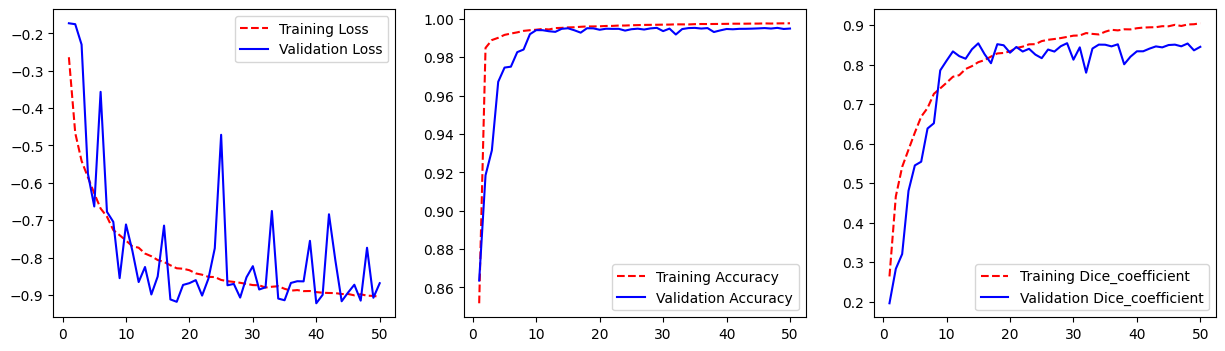

In [33]:
fig, axs = plt.subplots(1, 3, figsize = (15, 4))

training_loss = history.history['loss']
validation_loss = history.history['val_loss']

training_accuracy = history.history['binary_accuracy']
validation_accuracy = history.history['val_binary_accuracy']
training_dice = history.history['dice_coef']
validation_dice = history.history['val_dice_coef']
epoch_count = range(1, len(training_loss) + 1)

axs[0].plot(epoch_count, training_loss, 'r--')
axs[0].plot(epoch_count, validation_loss, 'b-')
axs[0].legend(['Training Loss', 'Validation Loss'])

axs[1].plot(epoch_count, training_accuracy, 'r--')
axs[1].plot(epoch_count, validation_accuracy, 'b-')
axs[1].legend(['Training Accuracy', 'Validation Accuracy'])

axs[2].plot(epoch_count, training_dice, 'r--')
axs[2].plot(epoch_count, validation_dice, 'b-')
axs[2].legend(['Training Dice_coefficient', 'Validation Dice_coefficient'])

In [42]:
test_folder="test/All"
folder=os.listdir(test_folder)
for case in folder:
    test_file_folder=os.path.join(test_folder,case)
    test_file_folder1=os.path.join(test_file_folder,"CY_AP_512x512")
    test_files=os.listdir(test_file_folder1)
    os.mkdir(os.path.join(test_file_folder,"results"))
    test_gen = test_generator(test_files, test_file_folder1,target_size=(512,512))
    results = model.predict_generator(test_gen, len(test_files), verbose=1)
    save_result(os.path.join(test_file_folder,"results"), results, test_files)

87/87 [==============================] - 5s 52ms/step


True

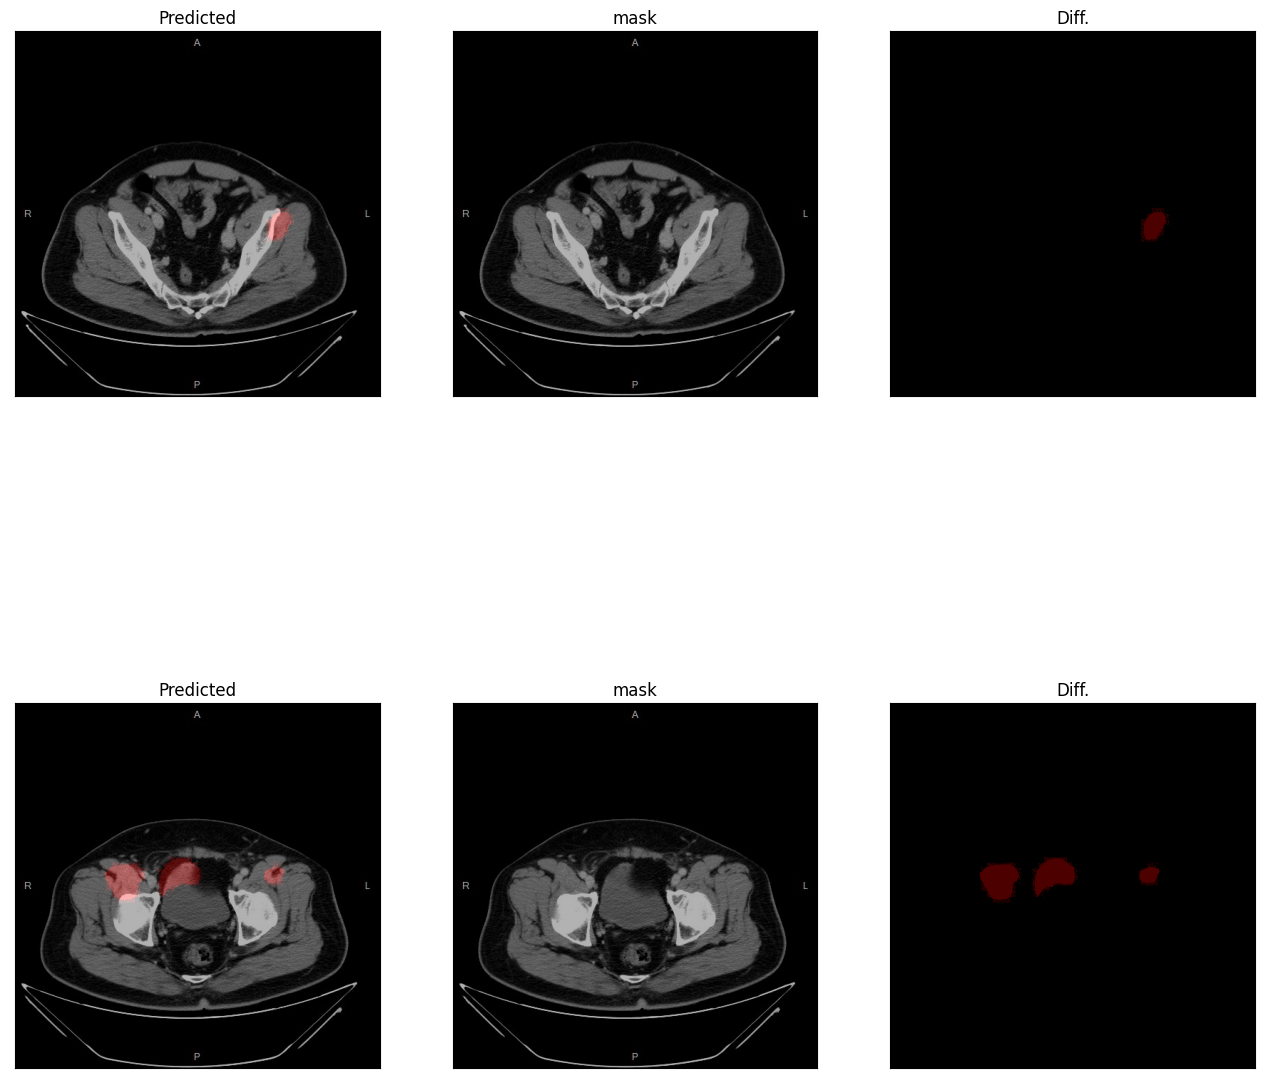

In [13]:
image = cv2.imread("test/case/image/73.jpg")
predict_image = cv2.imread("test/case/result/73_predict.jpg")
mask_image = cv2.imread("test/case/mask/73.jpg")

fig, axs = plt.subplots(2, 3, figsize=(16, 16))
list0=[]
axs[0, 0].set_title("Predicted")
axs[0, 0].axes.get_xaxis().set_visible(False)
axs[0, 0].axes.get_yaxis().set_visible(False)
axs[0, 0].imshow(add_colored_mask(image, predict_image))
axs[0, 1].set_title("mask")
axs[0, 1].axes.get_xaxis().set_visible(False)
axs[0, 1].axes.get_yaxis().set_visible(False)
axs[0, 1].imshow(add_colored_mask(image, mask_image))
axs[0, 2].set_title("Diff.")
axs[0, 2].axes.get_xaxis().set_visible(False)
axs[0, 2].axes.get_yaxis().set_visible(False)
axs[0, 2].imshow(diff_mask(mask_image, predict_image))
cv2.imwrite("1.jpg",cv2.cvtColor(add_colored_mask(image, predict_image),cv2.COLOR_RGB2BGR))
cv2.imwrite("2.jpg",cv2.cvtColor(add_colored_mask(image, mask_image),cv2.COLOR_RGB2BGR))
cv2.imwrite("3.jpg",cv2.cvtColor(diff_mask(mask_image, predict_image),cv2.COLOR_RGB2BGR))

image = cv2.imread("test/case/image/80.jpg")
predict_image = cv2.imread("test/case/result/80_predict.jpg")
mask_image = cv2.imread("test/case/mask/80.jpg")

axs[1, 0].set_title("Predicted")
axs[1, 0].axes.get_xaxis().set_visible(False)
axs[1, 0].axes.get_yaxis().set_visible(False)
axs[1, 0].imshow(add_colored_mask(image, predict_image))
axs[1, 1].set_title("mask")
axs[1, 1].axes.get_xaxis().set_visible(False)
axs[1, 1].axes.get_yaxis().set_visible(False)
axs[1, 1].imshow(add_colored_mask(image, mask_image))

axs[1, 2].set_title("Diff.")
axs[1, 2].axes.get_xaxis().set_visible(False)
axs[1, 2].axes.get_yaxis().set_visible(False)
axs[1, 2].imshow(diff_mask(mask_image, predict_image))


cv2.imwrite("4.jpg",cv2.cvtColor(add_colored_mask(image, predict_image),cv2.COLOR_RGB2BGR))
cv2.imwrite("5.jpg",cv2.cvtColor(add_colored_mask(image, mask_image),cv2.COLOR_RGB2BGR))
cv2.imwrite("6.jpg",cv2.cvtColor(diff_mask(mask_image, predict_image),cv2.COLOR_RGB2BGR))

In [8]:
model = load_model('unet_gallbladder_seg.hdf5', compile=False)

In [9]:
test_data_folder="test/image/"
test_files=[file for file in os.listdir(test_data_folder) if file.lower().endswith('.jpg')]
test_gen = test_generator(test_files,test_data_folder ,target_size=(512,512))
results = model.predict_generator(test_gen, len(test_files), verbose=1)
save_result("test/result/", results, test_files)

40/40 [==============================] - 9s 232ms/step
